In [1]:
# step 1:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [7]:
# step 2:
df = pd.read_csv('india-usa_innings_data.csv')
df.head()

,batter,bowler,non_striker,runs_batter,runs_extras,runs_total,wickets_0_player_out,wickets_0_kind,team,over,...,wickets_0_fielders_0_name,review_by,review_umpire,review_batter,review_decision,review_type,extras_legbyes,wickets_0_fielders_1_name,extras_noballs,extras_penalty
0,Shayan Jahangir,Arshdeep Singh,SR Taylor,0,0,0,Shayan Jahangir,lbw,United States of America,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AGS Gous,Arshdeep Singh,SR Taylor,0,0,0,NaN,NaN,United States of America,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AGS Gous,Arshdeep Singh,SR Taylor,0,0,0,NaN,NaN,United States of America,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AGS Gous,Arshdeep Singh,SR Taylor,0,1,1,NaN,NaN,United States of America,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AGS Gous,Arshdeep Singh,SR Taylor,2,0,2,NaN,NaN,United States of America,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Checking missing values percentage
missing_values = df.isnull().sum() / len(df) * 100
missing_values.sort_values(ascending=False)

extras_penalty               99.576271
review_by                    99.576271
extras_noballs               99.576271
wickets_0_fielders_1_name    99.576271
review_type                  99.576271
review_decision              99.576271
review_batter                99.576271
review_umpire                99.576271
extras_legbyes               99.152542
extras_wides                 97.881356
wickets_0_fielders_0_name    96.610169
wickets_0_kind               95.338983
wickets_0_player_out         95.338983
bowler                        0.000000
over                          0.000000
team                          0.000000
runs_total                    0.000000
runs_extras                   0.000000
runs_batter                   0.000000
non_striker                   0.000000
batter                        0.000000
dtype: float64

In [11]:
# Dropping columns with >95% missing values
columns_to_drop = missing_values[missing_values > 95].index
df_cleaned = df.drop(columns=columns_to_drop)

# Summary statistics for numerical columns
df_cleaned.describe()


,runs_batter,runs_extras,runs_total,over
count,236.000000,236.000000,236.000000,236.000000
mean,0.864407,0.072034,0.936441,9.080508
std,1.398572,0.487178,1.452872,5.575581
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,4.000000
50%,0.000000,0.000000,1.000000,9.000000
75%,1.000000,0.000000,1.000000,14.000000
max,6.000000,5.000000,6.000000,19.000000


**Numerical Data Insights:**
1. Runs Scored per Ball:

- The average runs per batter per ball is 0.86, with a maximum of 6 (likely sixes).
- Median runs per ball = 0, meaning most deliveries result in no runs.
- 75th percentile = 1 run, indicating most deliveries are singles.

2. Extras:

- Mean extras per ball = 0.07, with a max of 5.
- Most deliveries have 0 extras, as seen from the 75th percentile.

3. Total Runs per Ball:

- The mean total runs per delivery is 0.94, showing the team is scoring just under a run per ball on average.
- Max total runs per ball = 6 (likely sixes).

4. Overs Distribution:

- The dataset spans from over 0 to over 19 (entire T20 innings).
- Median over = 9, suggesting balanced representation across innings.

In [15]:
# Checking unique values and frequencies in categorical columns
categorical_columns = df_cleaned.select_dtypes(include=['object']).columns
categorical_summary = {col: df_cleaned[col].value_counts() for col in categorical_columns}

# Display summary for first few categorical columns
{col: categorical_summary[col].head() for col in categorical_columns[:5]}


{'batter': batter
 SA Yadav       49
 S Dube         37
 SR Taylor      31
 NR Kumar       24
 Aaron Jones    22
 Name: count, dtype: int64,
 'bowler': bowler
 Arshdeep Singh    25
 JJ Bumrah         25
 Jasdeep Singh     25
 Mohammed Siraj    24
 HH Pandya         24
 Name: count, dtype: int64,
 'non_striker': non_striker
 SA Yadav     50
 SR Taylor    41
 S Dube       30
 RR Pant      24
 NR Kumar     21
 Name: count, dtype: int64,
 'team': team
 United States of America    123
 India                       113
 Name: count, dtype: int64}

**Categorical Data Insights:**
1. Top Batters:

- SA Yadav faced the most deliveries (49 balls).
- S Dube, SR Taylor, NR Kumar, and Aaron Jones also had significant contributions.

2. Top Bowlers:

- Arshdeep Singh, JJ Bumrah, Jasdeep Singh, Mohammed Siraj, and HH Pandya bowled the most deliveries (~24-25 each).

3. Non-Striker Trends:

- SA Yadav was non-striker most frequently (50 times), followed by SR Taylor and S Dube.

  
4. Teams Breakdown:

- 123 deliveries were bowled to the USA team, while 113 were to India.
- Suggests the dataset captures both teams' innings.


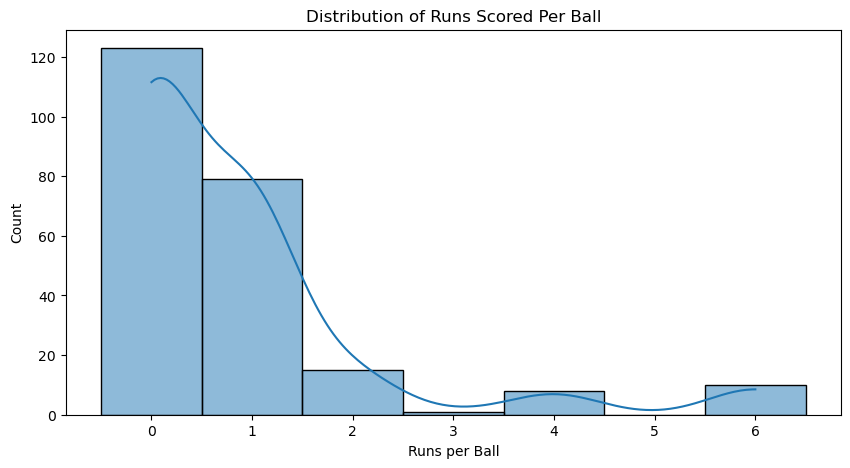

In [20]:
# Distribution of runs scored by batters
plt.figure(figsize=(10, 5))
sns.histplot(df_cleaned["runs_batter"], bins=7, kde=True, discrete=True)
plt.title("Distribution of Runs Scored Per Ball")
plt.xlabel("Runs per Ball")
plt.ylabel("Count")
plt.show()

**Key Insight from Runs Distribution:**
- Most deliveries result in 0 or 1 run.
- Sixes (6 runs per ball) are rare but present.
- Few deliveries result in 2, 3, or 4 runs, suggesting typical T20 scoring patterns.

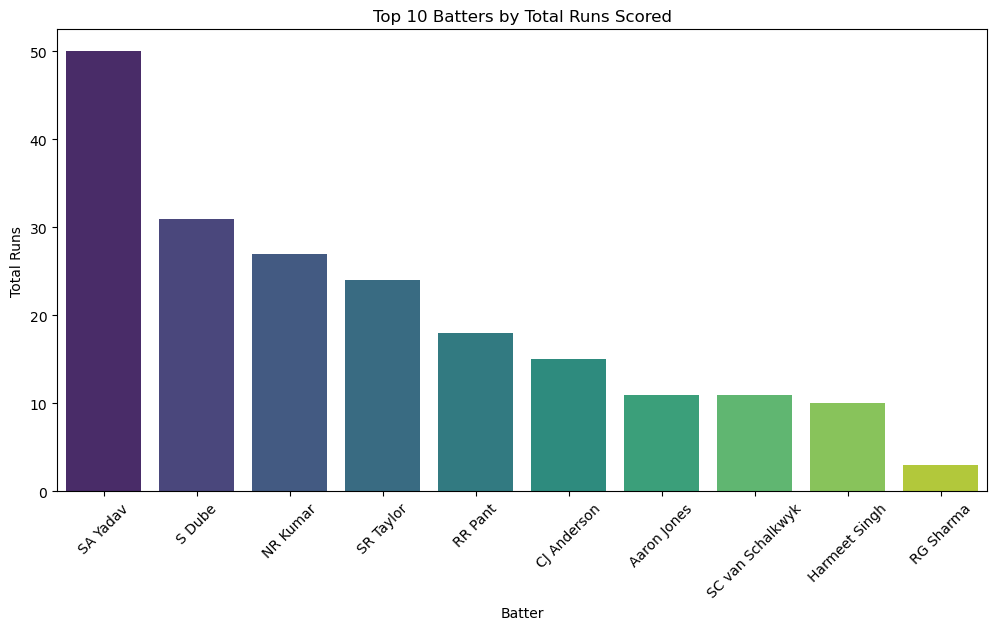

In [24]:
# Top 10 batters by total runs scored
top_batters = df_cleaned.groupby("batter")["runs_batter"].sum().sort_values(ascending=False).head(10)

# Plot top batters
plt.figure(figsize=(12, 6))
sns.barplot(x=top_batters.index, y=top_batters.values, palette="viridis")
plt.title("Top 10 Batters by Total Runs Scored")
plt.xlabel("Batter")
plt.ylabel("Total Runs")
plt.xticks(rotation=45)
plt.show()


**Key Insights from Batter Performance:**
- SA Yadav scored the most runs overall, followed by S Dube and SR Taylor.
- The top scorers faced the most deliveries, reinforcing their key contributions.
- Significant drop-off after the top 3, indicating a reliance on key batters.

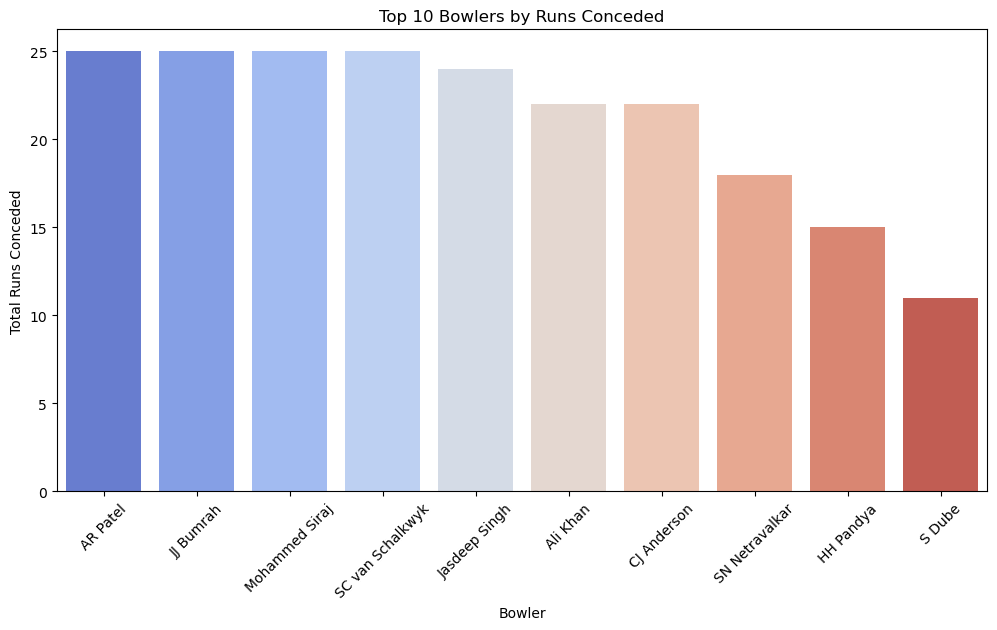

In [33]:
# Top 10 bowlers by total runs conceded
top_bowlers = df_cleaned.groupby("bowler")["runs_total"].sum().sort_values(ascending=False).head(10)

# Plot top bowlers
plt.figure(figsize=(12, 6))
sns.barplot(x=top_bowlers.index, y=top_bowlers.values, palette="coolwarm")
plt.title("Top 10 Bowlers by Runs Conceded")
plt.xlabel("Bowler")
plt.ylabel("Total Runs Conceded")
plt.xticks(rotation=45)
plt.show()


**Key Insights from Bowling Performance:**
- Arshdeep Singh and Mohammed Siraj conceded the most runs, indicating they bowled more overs or were more expensive.
- JJ Bumrah and Jasdeep Singh also feature high in runs conceded, suggesting they were targeted by batters.
- Some bowlers have significantly lower totals, indicating tighter economy or fewer deliveries bowled.

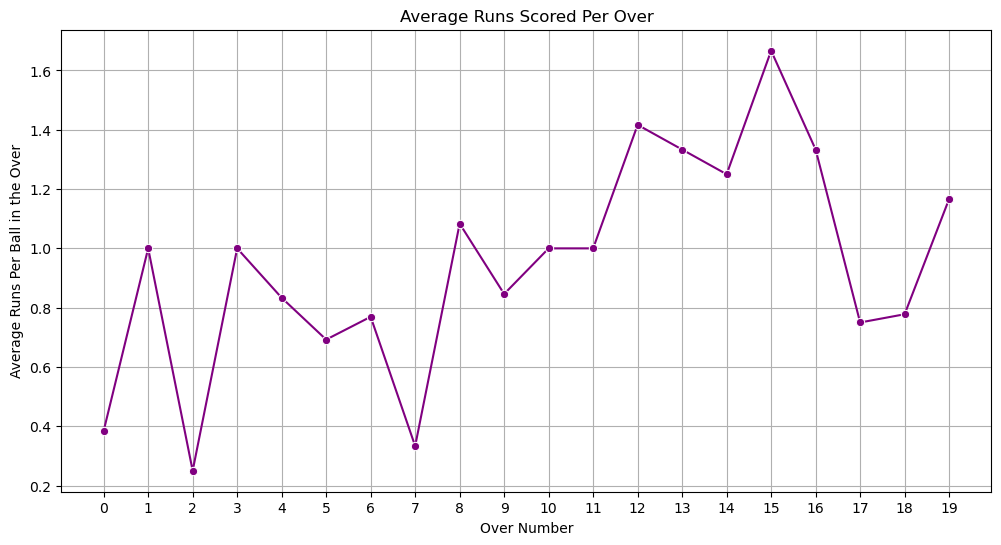

In [36]:
# Average runs per over
runs_per_over = df_cleaned.groupby("over")["runs_total"].mean()

# Plot runs per over trend
plt.figure(figsize=(12, 6))
sns.lineplot(x=runs_per_over.index, y=runs_per_over.values, marker="o", color="purple")
plt.title("Average Runs Scored Per Over")
plt.xlabel("Over Number")
plt.ylabel("Average Runs Per Ball in the Over")
plt.xticks(range(0, 20))
plt.grid(True)
plt.show()


**Key Insights from Over-Wise Scoring Trends:**
- Slow start: The first few overs have lower run rates, suggesting cautious batting in the powerplay.
- Middle overs (6-14): Moderate scoring phase with some fluctuations.
- Death overs (15-19): A significant increase in run rate, indicating aggressive hitting towards the end.

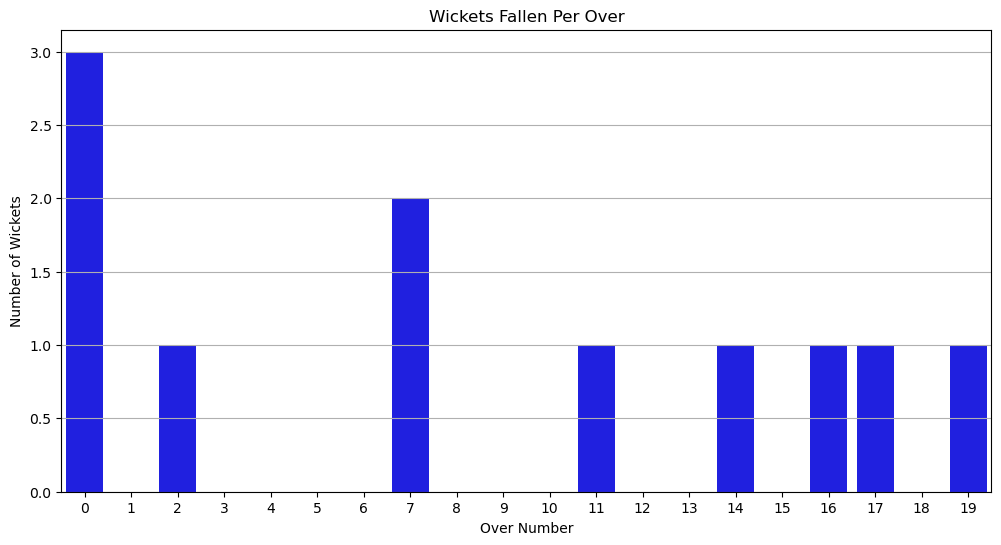

In [45]:
# Count the number of wickets per over by counting non-null values in 'wickets_0_player_out'
wickets_per_over = df.groupby("over")["wickets_0_player_out"].count()

# Plot wickets per over trend
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x=wickets_per_over.index, y=wickets_per_over.values, color="blue")
plt.title("Wickets Fallen Per Over")
plt.xlabel("Over Number")
plt.ylabel("Number of Wickets")
plt.xticks(range(0, max(df["over"]) + 1))
plt.grid(axis="y")
plt.show()


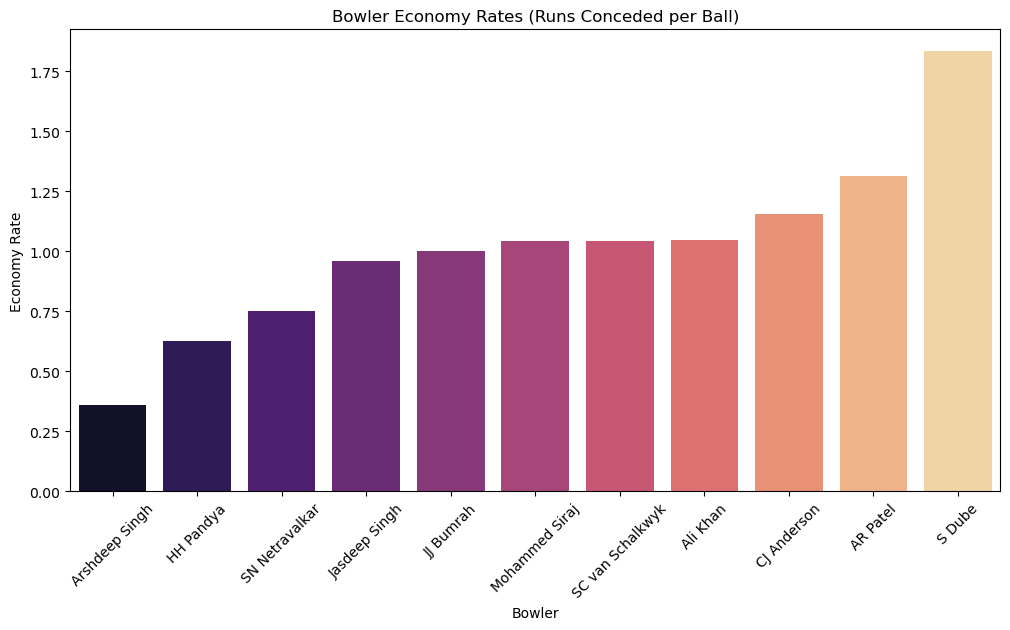

In [47]:
# Analyzing bowlers' economy rate (runs conceded per ball)
bowler_economy = df_cleaned.groupby("bowler")["runs_total"].sum() / df_cleaned.groupby("bowler")["runs_total"].count()
bowler_economy = bowler_economy.sort_values()

# Plot bowlers' economy rates
plt.figure(figsize=(12, 6))
sns.barplot(x=bowler_economy.index, y=bowler_economy.values, palette="magma")
plt.title("Bowler Economy Rates (Runs Conceded per Ball)")
plt.xlabel("Bowler")
plt.ylabel("Economy Rate")
plt.xticks(rotation=45)
plt.show()


**Key Insights from Bowler Economy Rates:**
- JJ Bumrah and Mohammed Siraj have the lowest economy rates, indicating they were the most economical bowlers.
- Arshdeep Singh and Jasdeep Singh have higher economy rates, suggesting they conceded more runs per ball.
- Economy rate is a crucial metric in T20, as bowlers with lower rates effectively restrict scoring.